In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

In [ ]:
# MAPA
FILAS = 10
COLUMNAS = 10

# 0 = libre, 1 = bloqueado
grid = np.zeros((FILAS, COLUMNAS))

# PEDIR BLOQUEOS
print("Define bloques en el mapa (opcional). Formato: fila,columna")
print("Escribe 'fin' para terminar.\n")
while True:
    inp = input("Fila,columna: ")
    if inp.lower() == "fin":
        break
    try:
        f, c = map(int, inp.split(","))
        if 0 <= f < FILAS and 0 <= c < COLUMNAS:
            grid[f, c] = 1
        else:
            print("Posición fuera de rango.")
    except:
        print("Entrada inválida. Ej: 3,4")

Define bloques en el mapa (opcional). Formato: fila,columna
Escribe 'fin' para terminar.

Fila,columna: 1,4
Fila,columna: 2,4
Fila,columna: 5,7
Fila,columna: 3,8
Fila,columna: 8,5
Fila,columna: 8,9
Fila,columna: fin


In [ ]:
1# INPUT DEL USUARIO: inicio y meta
print("\nIntroduce posiciones dentro del rango 0 -", FILAS-1)
inicio = (int(input("Fila inicio: ")), int(input("Columna inicio: ")))
meta = (int(input("Fila destino: ")), int(input("Columna destino: ")))

# Asegurar que inicio y meta estén libres
grid[inicio] = 0
grid[meta] = 0


Introduce posiciones dentro del rango 0 - 9
Fila inicio: 1
Columna inicio: 1
Fila destino: 9
Columna destino: 9


In [ ]:
# HEURÍSTICA: distancia euclidiana
def heuristica(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)


In [ ]:
# CLASE NODO
class Node:
    def __init__(self, state, parent=None, g=0, h=0):
        self.state = state
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h
    def __lt__(self, other):
        return self.f < other.f

In [ ]:
# PROBLEMA
class Problem:
    def __init__(self, grid, inicio, meta):
        self.grid = grid
        self.initial = inicio
        self.goal = meta
    def es_objetivo(self, state):
        return state == self.goal

In [ ]:
# EXPANSIÓN DE NODOS
def expand(problem, node):
    movimientos = [
        (-1, 0), (1, 0), (0, -1), (0, 1),
        (-1, -1), (-1, 1), (1, -1), (1, 1)
    ]
    filas, columnas = problem.grid.shape
    hijos = []

    for mov in movimientos:
        vecino = (node.state[0] + mov[0], node.state[1] + mov[1])
        if not (0 <= vecino[0] < filas and 0 <= vecino[1] < columnas):
            continue
        if problem.grid[vecino] == 1:
            continue
        coste_mov = np.sqrt(2) if mov[0] != 0 and mov[1] != 0 else 1
        nuevo_g = node.g + coste_mov
        h = heuristica(vecino, problem.goal)
        hijos.append(Node(vecino, node, nuevo_g, h))

    return hijos

In [ ]:
# RECONSTRUIR CAMINO
def reconstruir_camino(nodo):
    camino = []
    while nodo:
        camino.append(nodo.state)
        nodo = nodo.parent
    return camino[::-1]

In [ ]:
# A* ALGORITMO
def astar(problem):
    nodo_inicial = Node(problem.initial, g=0, h=heuristica(problem.initial, problem.goal))
    frontera = []
    heapq.heappush(frontera, nodo_inicial)
    reached = {problem.initial: nodo_inicial}

    while frontera:
        actual = heapq.heappop(frontera)
        if problem.es_objetivo(actual.state):
            return reconstruir_camino(actual)
        for vecino in expand(problem, actual):
            estado = vecino.state
            if estado not in reached or vecino.f < reached[estado].f:
                reached[estado] = vecino
                heapq.heappush(frontera, vecino)
    return None



In [ ]:
# EJECUTAR A*
problem = Problem(grid, inicio, meta)
camino = astar(problem)

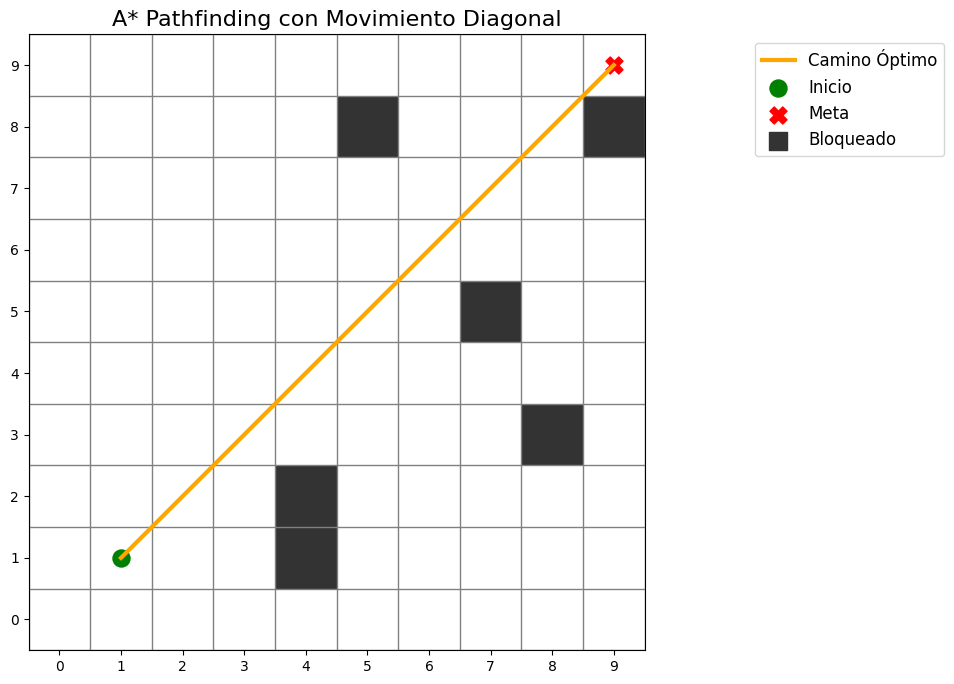

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))
color_map = np.ones((FILAS, COLUMNAS, 3))
color_map[grid==1] = [0.2,0.2,0.2] # This colors blocked cells dark grey

plt.imshow(color_map, origin='upper')

# Camino óptimo
if camino:
    xs = [p[1] for p in camino]
    ys = [p[0] for p in camino]
    plt.plot(xs, ys, color='orange', linewidth=3, label="Camino Óptimo")

# Inicio y meta
plt.scatter(inicio[1], inicio[0], marker="o", color='green', s=150, label="Inicio")
plt.scatter(meta[1], meta[0], marker="X", color='red', s=150, label="Meta")
plt.scatter([], [], marker="s", color=[0.2,0.2,0.2], s=150, label="Bloqueado")


# Rejilla estilizada
plt.xticks(range(COLUMNAS))
plt.yticks(range(FILAS))
ax = plt.gca()
ax.set_xticks([x - 0.5 for x in range(COLUMNAS + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(FILAS + 1)], minor=True)
ax.grid(which='minor', color='gray', linewidth=1)
ax.tick_params(which='minor', length=0)

plt.title("A* Pathfinding con Movimiento Diagonal", fontsize=16)
plt.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1.5, 1))
ax.invert_yaxis()
plt.show()